In [21]:
#import
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from flaml import AutoML

In [22]:
# Load data
batting = pd.read_csv('baseball-reference data/all_batting_updated.csv')
pitching = pd.read_csv('baseball-reference data/all_pitching_updated.csv')
hof_batting = pd.read_csv('baseball-reference data/hof_batting_updated.csv')
hof_pitching = pd.read_csv('baseball-reference data/hof_pitching_updated.csv')

In [23]:
#Preprocess data

#drops invalid cols
batting = batting.drop(['IDfg','Team'],axis=1)
pitching = pitching.drop(['IDfg','Team'],axis=1)
hof_batting = hof_batting.drop('Rk',axis=1)
hof_pitching = hof_pitching.drop('Rk',axis=1)

# Label Hall of Fame players
hof_batting['HOF'] = 1
hof_pitching['HOF'] = 1

# Merge stats of all players with Hall of Fame labels
batting = batting.merge(hof_batting[['playerID', 'HOF']], on='playerID', how='left')
pitching = pitching.merge(hof_pitching[['playerID', 'HOF']], on='playerID', how='left')

# Fill missing HOF labels with 0 (not in Hall of Fame)
batting['HOF'] = batting['HOF'].fillna(0)
pitching['HOF'] = pitching['HOF'].fillna(0)

print('Batting:')
print(batting.head())
print('\nPitching:')
print(pitching.head())



Batting:
   Season           Name  Age    G   AB   PA    H   1B  2B  3B  ...  CStr%  \
0    2002    Barry Bonds   37  143  403  612  149   70  31   2  ...  0.127   
1    2001    Barry Bonds   36  153  476  664  156   49  32   2  ...    NaN   
2    2004    Barry Bonds   39  147  373  617  135   60  27   3  ...  0.124   
3    1946   Ted Williams   27  150  514  672  176   93  37   8  ...    NaN   
4    1956  Mickey Mantle   24  150  533  652  188  109  22   5  ...    NaN   

    CSW%  xBA  xSLG  xwOBA  L-WAR  first_name  last_name   playerID  HOF  
0  0.191  NaN   NaN    NaN   12.7       Barry      Bonds  bondsba01  0.0  
1    NaN  NaN   NaN    NaN   12.5       Barry      Bonds  bondsba01  0.0  
2  0.164  NaN   NaN    NaN   11.9       Barry      Bonds  bondsba01  0.0  
3    NaN  NaN   NaN    NaN   11.6         Ted   Williams  willite01  1.0  
4    NaN  NaN   NaN    NaN   11.5      Mickey     Mantle  mantlmi01  1.0  

[5 rows x 322 columns]

Pitching:
   Season            Name  Age   W   

In [24]:
# Select relevant features (excluding playerID and other non-numeric columns)
batting_features = batting.select_dtypes(include=['number']).drop(columns=['HOF']).fillna(0)
pitching_features = pitching.select_dtypes(include=['number']).drop(columns=['HOF']).fillna(0)
y_batting = batting['HOF']
y_pitching = pitching['HOF']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res_b, y_res_b = smote.fit_resample(batting_features, y_batting)
X_res_p, y_res_p = smote.fit_resample(pitching_features, y_pitching)

# Stratified split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_res_b, y_res_b, test_size=0.2, random_state=42, stratify=y_res_b)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_res_p, y_res_p, test_size=0.2, random_state=42, stratify=y_res_p)

# Scale features
scaler = StandardScaler()
X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)
X_train_p_scaled = scaler.fit_transform(X_train_p)
X_test_p_scaled = scaler.transform(X_test_p)


In [25]:
# Train XGBoost models
batting_model = xgb.XGBClassifier(eval_metric='logloss')
pitching_model = xgb.XGBClassifier(eval_metric='logloss')

batting_model.fit(X_train_b_scaled, y_train_b)
pitching_model.fit(X_train_p_scaled, y_train_p)

# Saving models
'''with open("models/batting_model.pkl", "wb") as f:
    pickle.dump(batting_model, f)

with open("models/pitching_model.pkl", "wb") as f:
    pickle.dump(pitching_model, f)'''

'with open("models/batting_model.pkl", "wb") as f:\n    pickle.dump(batting_model, f)\n\nwith open("models/pitching_model.pkl", "wb") as f:\n    pickle.dump(pitching_model, f)'

In [26]:
# Predictions
y_pred_b = batting_model.predict(X_test_b_scaled)
y_pred_p = pitching_model.predict(X_test_p_scaled)

In [27]:
# Evaluation
print("Batting Model Performance:")
print(accuracy_score(y_test_b, y_pred_b))
print(classification_report(y_test_b, y_pred_b))

print("\nPitching Model Performance:")
print(accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))

Batting Model Performance:
0.9580557611645695
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      2027
         1.0       0.96      0.95      0.96      2026

    accuracy                           0.96      4053
   macro avg       0.96      0.96      0.96      4053
weighted avg       0.96      0.96      0.96      4053


Pitching Model Performance:
0.9685099846390169
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      1302
         1.0       0.97      0.97      0.97      1302

    accuracy                           0.97      2604
   macro avg       0.97      0.97      0.97      2604
weighted avg       0.97      0.97      0.97      2604



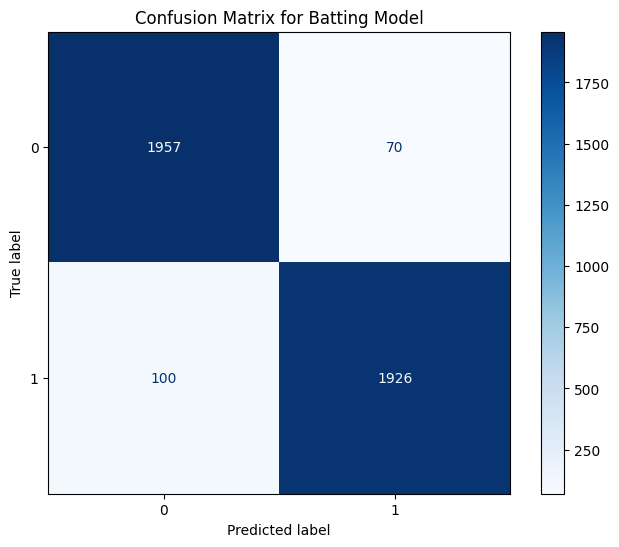

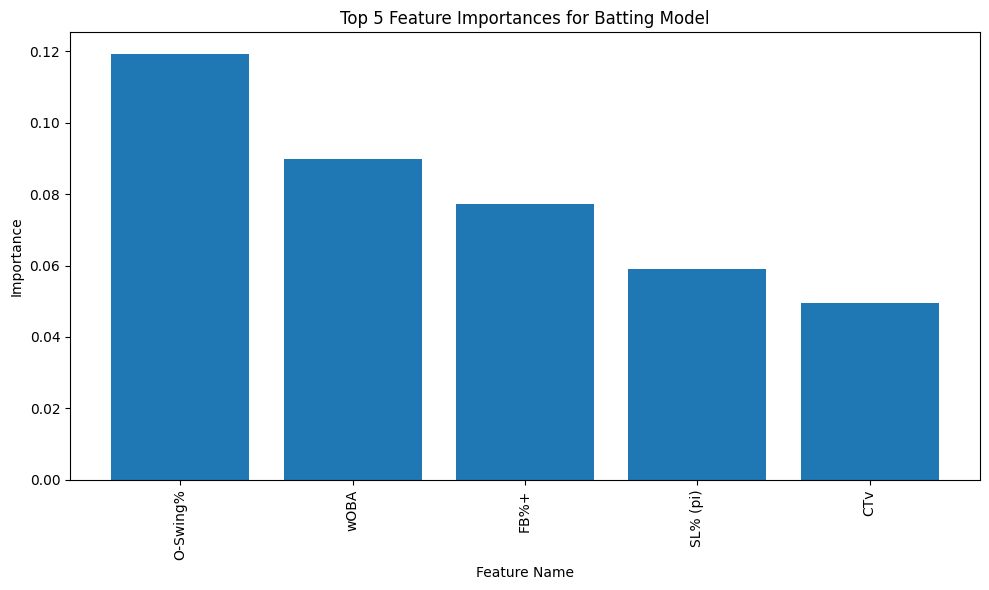

In [28]:
# Generate confusion matrix
cm_batting = confusion_matrix(y_test_b, y_pred_b)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_batting, display_labels=batting_model.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Batting Model')
plt.show()

# Get feature importances
feature_importances = batting_model.feature_importances_

# Get feature names
feature_names = batting_features.columns

# Sort feature importances in descending order
sorted_importances = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Select top 5 features
top_5_features = sorted_importances[:5]

# Extract feature names and importances
top_5_names = [x[0] for x in top_5_features]
top_5_importances = [x[1] for x in top_5_features]

# Plot top 5 feature importances
plt.figure(figsize=(10, 6))
plt.bar(top_5_names, top_5_importances)
plt.title('Top 5 Feature Importances for Batting Model')
plt.xlabel('Feature Name')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


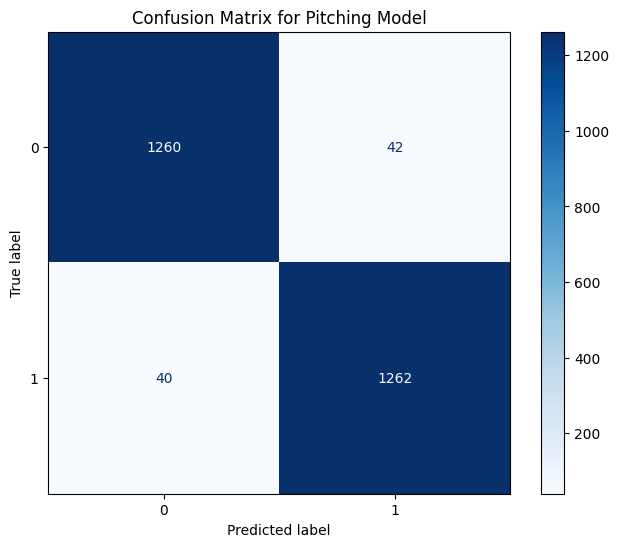

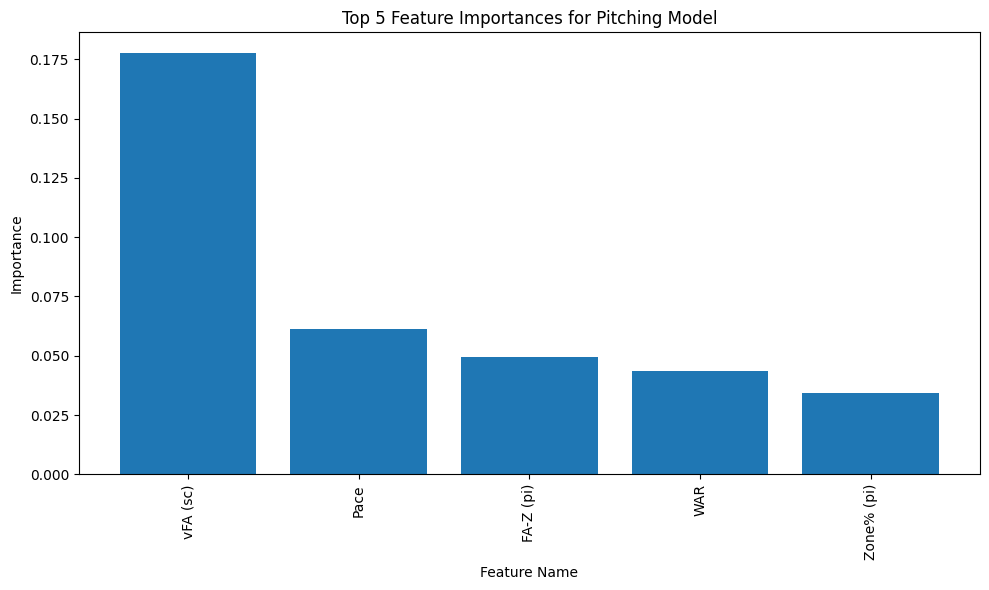

In [29]:
# Generate confusion matrix
cm_pitching = confusion_matrix(y_test_p, y_pred_p)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pitching, display_labels=pitching_model.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Pitching Model')
plt.show()

# Get feature importances
feature_importances = pitching_model.feature_importances_

# Get feature names
feature_names = pitching_features.columns

# Sort feature importances in descending order
sorted_importances = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Select top 5 features
top_5_features = sorted_importances[:5]

# Extract feature names and importances
top_5_names = [x[0] for x in top_5_features]
top_5_importances = [x[1] for x in top_5_features]

# Plot top 5 feature importances
plt.figure(figsize=(10, 6))
plt.bar(top_5_names, top_5_importances)
plt.title('Top 5 Feature Importances for Pitching Model')
plt.xlabel('Feature Name')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [30]:
#load data
batter = pd.read_csv('dodgers 2024/shohei-batting.csv')
pitcher = pd.read_csv('dodgers 2024/shohei-pitching.csv')

print('Batting:')
print(batter.head())
print('\nPitching:')
print(pitcher.head())


Batting:
   Season  Age Team  Lg  WAR    G   PA   AB    R    H  ...   rOBA  Rbat+   TB  \
0    2018   23  LAA  AL  2.7  104  367  326   59   93  ...  0.389    148  184   
1    2019   24  LAA  AL  2.4  106  425  384   51  110  ...  0.370    127  194   
2    2020   25  LAA  AL  0.0   44  175  153   23   29  ...  0.301     78   56   
3    2021   26  LAA  AL  4.9  155  639  537  103  138  ...  0.399    153  318   
4    2022   27  LAA  AL  3.4  157  666  586   90  160  ...  0.371    142  304   

   GIDP  HBP  SH  SF  IBB      Pos        Awards  
0     2    2   0   1    2      DH1         ROY-1  
1     6    2   0   4    1       DH           NaN  
2     3    0   0   0    0     D/H1           NaN  
3     7    4   0   2   20  *D1/H97     ASMVP-1SS  
4     6    5   0   3   14    *D1/H  ASCYA-4MVP-2  

[5 rows x 33 columns]

Pitching:
   Season   Age Team   Lg  WAR     W    L   W-L%    ERA     G  ...     BF  \
0  2018.0  23.0  LAA   AL  1.3   4.0  2.0  0.667   3.31  10.0  ...  211.0   
1     NaN 

In [31]:
#preprocess
batter = batter.drop(columns=['Team','Pos','Awards','Lg'], errors='ignore')
pitcher = pitcher.drop(columns=['Team','Awards'], errors='ignore')

with open("models/batting_model.pkl", "rb") as f:
    batting_model = pickle.load(f)

with open("models/pitching_model.pkl", "rb") as f:
    pitching_model = pickle.load(f)

batter = batter.select_dtypes(include=['number']).fillna(0)
pitcher = pitcher.select_dtypes(include=['number']).fillna(0)

# Predict HoF induction for batting
batting_pred = batting_model.predict(batter)
batting_prob = batting_model.predict_proba(batter)[:, 1]  # Probability of HoF induction

# Predict HoF induction for pitching
pitching_pred = pitching_model.predict(pitcher)
pitching_prob = pitching_model.predict_proba(pitcher)[:, 1]  # Probability of HoF induction

# Print results
print(f"Batting HoF Prediction: {batting_pred[0]}, Probability: {batting_prob[0]:.2f}")
print(f"Pitching HoF Prediction: {pitching_pred[0]}, Probability: {pitching_prob[0]:.2f}")


ValueError: Feature shape mismatch, expected: 315, got 29

In [37]:
# Initialize AutoML for batting data
automl_batting = AutoML()

# Fit the AutoML model with time budget (in seconds)
automl_batting.fit(
    X_train_b_scaled, 
    y_train_b,
    task="classification",
    time_budget=180,  # Adjust time budget as needed
    metric="accuracy",
    estimator_list=["xgboost", "rf", "extra_tree", "sgd"]
)

# Get predictions
y_pred_automl_b = automl_batting.predict(X_test_b_scaled)

# Evaluate the model
print("AutoML Batting Model Performance:")
print(f"Accuracy: {accuracy_score(y_test_b, y_pred_automl_b)}")
print(classification_report(y_test_b, y_pred_automl_b))

# Similarly for pitching data
automl_pitching = AutoML()
automl_pitching.fit(
    X_train_p_scaled, 
    y_train_p,
    task="classification",
    time_budget=180,
    metric="accuracy",
    estimator_list=["xgboost", "rf", "extra_tree", "sgd"]
)

y_pred_automl_p = automl_pitching.predict(X_test_p_scaled)
print("\nAutoML Pitching Model Performance:")
print(f"Accuracy: {accuracy_score(y_test_p, y_pred_automl_p)}")
print(classification_report(y_test_p, y_pred_automl_p))

# Get details about the best model found by AutoML
print("\nBest Batting Model:")
print(f"Best ML learner: {automl_batting.best_estimator}")
print(f"Best hyperparameter config: {automl_batting.best_config}")
print(f"Best accuracy: {1 - automl_batting.best_loss}")
print(f"Training time: {automl_batting.best_config_train_time}s")

[flaml.automl.logger: 03-28 22:40:11] {1728} INFO - task = classification
[flaml.automl.logger: 03-28 22:40:11] {1739} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-28 22:40:11] {1838} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 03-28 22:40:11] {1955} INFO - List of ML learners in AutoML Run: ['xgboost', 'rf', 'extra_tree', 'sgd']
[flaml.automl.logger: 03-28 22:40:11] {2258} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 03-28 22:40:11] {2393} INFO - Estimated sufficient time budget=1762s. Estimated necessary time budget=2s.
[flaml.automl.logger: 03-28 22:40:11] {2442} INFO -  at 0.3s,	estimator xgboost's best error=0.2440,	best estimator xgboost's best error=0.2440
[flaml.automl.logger: 03-28 22:40:11] {2258} INFO - iteration 1, current learner sgd
[flaml.automl.logger: 03-28 22:40:13] {2442} INFO -  at 2.1s,	estimator sgd's best error=0.2335,	best estimator sgd's best error=0.2335
[flaml.automl.logger: 03-28 22:40:13] {2258} INFO -


XGBoost Batting:
Accuracy: 0.9581


<Figure size 800x600 with 0 Axes>

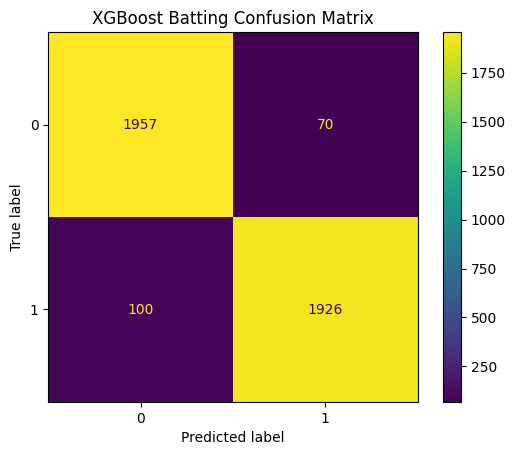


FLAML Batting:
Accuracy: 0.9667


<Figure size 800x600 with 0 Axes>

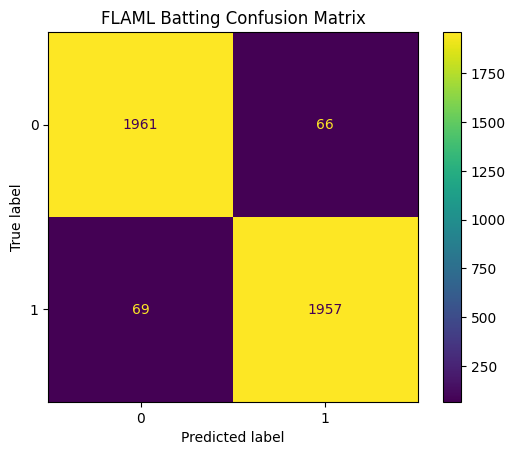


XGBoost Pitching:
Accuracy: 0.9685


<Figure size 800x600 with 0 Axes>

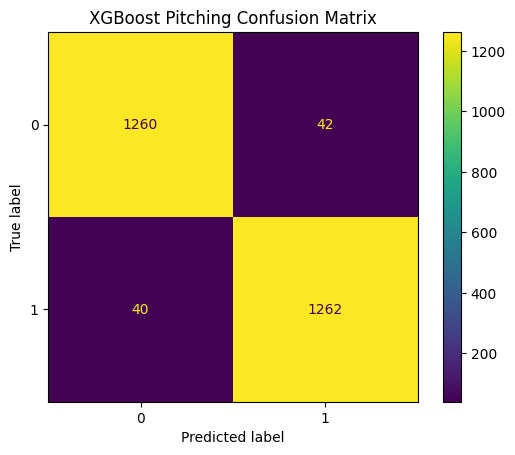


FLAML Pitching:
Accuracy: 0.9762


<Figure size 800x600 with 0 Axes>

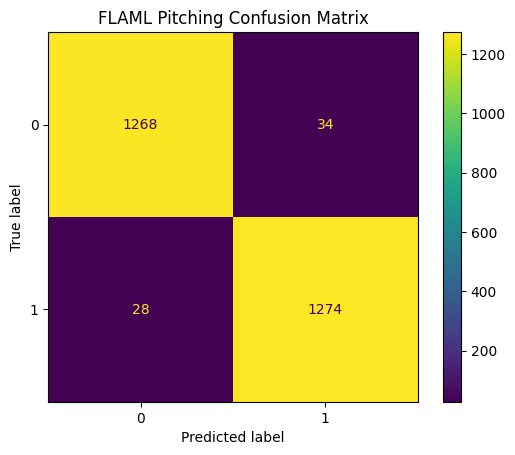

In [38]:
# Comparison between XGBoost and FLAML
models = {
    "XGBoost Batting": (y_test_b, y_pred_b),
    "FLAML Batting": (y_test_b, y_pred_automl_b),
    "XGBoost Pitching": (y_test_p, y_pred_p),
    "FLAML Pitching": (y_test_p, y_pred_automl_p)
}

# Create a comparison table
for model_name, (y_true, y_pred) in models.items():
    print(f"\n{model_name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()